# Greenland Student Kramers M4 research workflow

This notebook is the interactive index of the M4 study. It follows the same
order as the previous project: simulation validation, real-data fitting,
predictive diagnostics, bootstrap uncertainty, and IOS goodness-of-fit.

Long calculations are run by command modules and saved as checkpoints. The
cells below load the versioned report snapshot and call reusable plotting
functions.


## Evidence status

- **Current evidence** uses the globally feasible Cholesky M4 optimizer.
- **Development evidence** records earlier recovery, discrimination, and
  M3-null bootstrap runs made before the Cholesky parameterization.

Current replacements now exist for recovery, discrimination, and the
M3-null nested comparison. Development results remain available only as a
record of the earlier optimization strategy.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from greenland_application.data_loading import load_real_data
from greenland_application.figures import (
    plot_discrimination,
    plot_ios_numerical_diagnostics,
    plot_ios_overview,
    plot_ios_phase_space,
    plot_m4_diffusion_audit,
    plot_m4_parameter_distributions,
    plot_m4_parametric_bootstrap_diffusion,
    plot_m4_parametric_bootstrap_parameters,
    plot_modelwise_ios_bootstrap,
    plot_nested_bootstrap,
    plot_nested_bootstrap_diagnostics,
    plot_predictive_densities,
    plot_predictive_percentiles,
    plot_real_data_mechanisms,
    plot_real_data_state_space,
    plot_recovery_study,
    plot_transition_improvement,
    plot_waiting_time_comparison,
)
from student_kramers import config
from student_kramers.models import PARAM_NAMES

CURRENT = ROOT / "docs" / "results" / "current"
DEVELOPMENT = ROOT / "docs" / "results" / "development"


/Users/sal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
_, age, x, data = load_real_data()
fits = pd.read_csv(CURRENT / "model_fits.csv")
m4_params = fits.loc[fits["model"] == "M4", PARAM_NAMES].iloc[0].to_numpy(float)
fits[["model", "nll", "aic", "bic", "q_min_global", "q_min_observed"]]


,model,nll,aic,bic,q_min_global,q_min_observed
0,M2,8524.347708,17060.695416,17095.637291,4176.668090,4176.668090
1,M3,8524.058929,17064.117858,17110.707026,4167.946212,4167.946212
2,M4,8499.311650,17020.623299,17084.683404,0.000276,3867.032067


## 1. Data and observation scheme

Only the climate coordinate \(X\) is observed. The partial likelihood uses

$$
\widehat V_k = \frac{X_{k+1}-X_k}{h}, \qquad h=0.02\ \mathrm{kyr}.
$$

The following figure shows the time series, reconstructed velocity, observed
phase space, and where M4 changes diffusion relative to M3.


/Users/sal/Desktop/Statistic Project/student-kramers-m4/greenland_application/figures.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


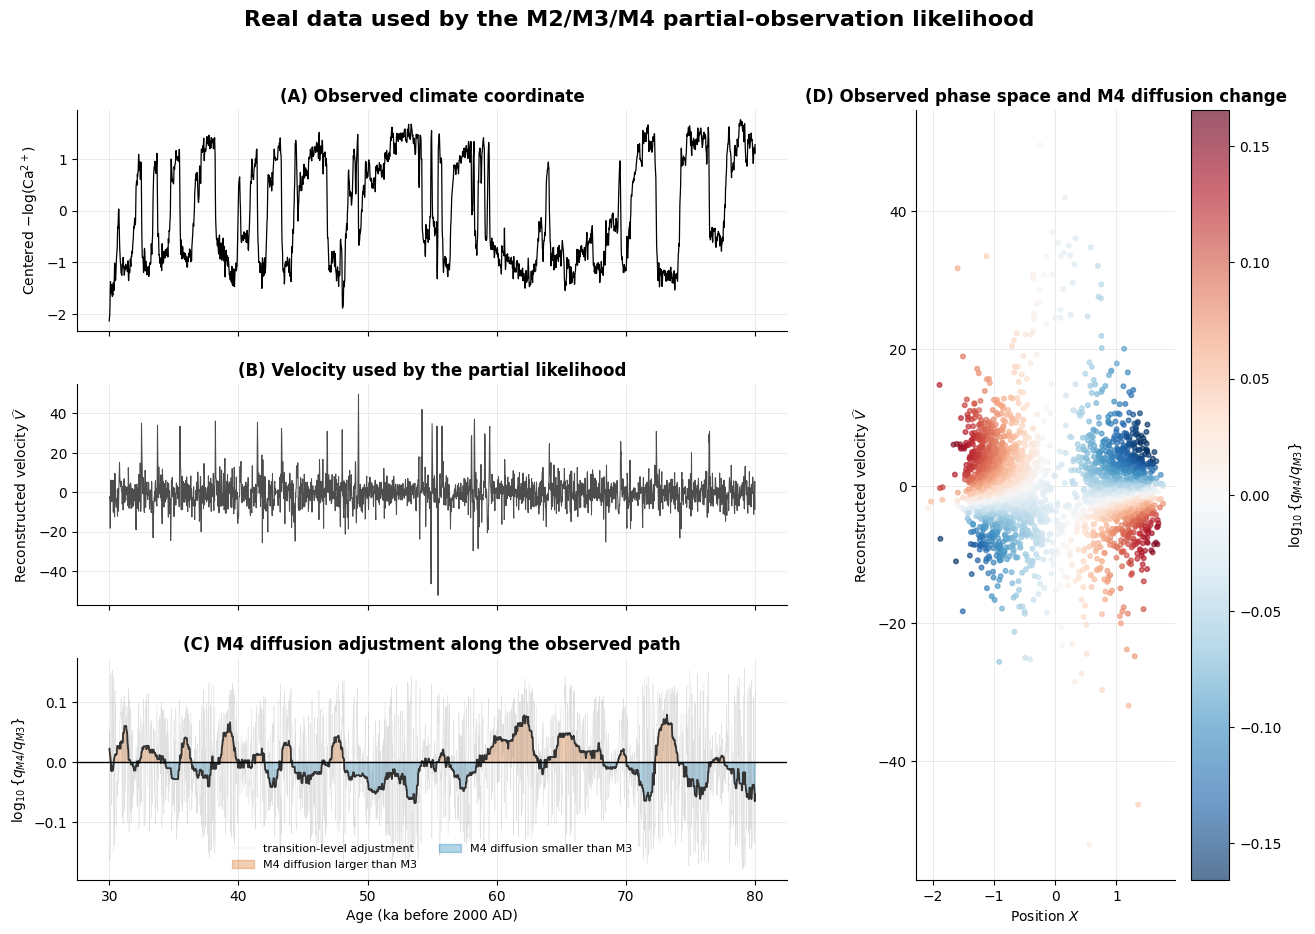

In [3]:
plot_real_data_state_space(age, x, data, fits)
plt.show()


## 2. Simulation validation

The current simulation programme contains:

1. complete-data recovery using latent \((X,V)\);
2. partial-data recovery after discarding \(V\) and reconstructing
   \(\widehat V\);
3. repeated M3 and M4 recovery;
4. M3/M4 discrimination under M3 and weak, moderate, and strong M4 truth.

The tables below use the current Cholesky optimizer. Each recovery design has
100 paths, and each discrimination scenario has 100 paths.


In [4]:
recovery = []
for model in ("M3", "M4"):
    table = pd.read_csv(CURRENT / f"{model.lower()}_recovery_study.csv")
    table["model"] = model
    recovery.append(table)
recovery = pd.concat(recovery, ignore_index=True)
recovery.groupby(["model", "observation"]).agg(
    n=("success", "size"),
    success_rate=("success", "mean"),
    median_q_relative_rmse=("q_path_relative_rmse", "median"),
    median_seconds=("time_sec", "median"),
)


n  success_rate  median_q_relative_rmse  median_seconds
model observation                                                           
M3    complete     100           1.0                0.096174        0.813076
      partial      100           1.0                0.196765        3.283372
M4    complete     100           1.0                0.119005        6.629940
      partial      100           1.0                0.215865       28.064370

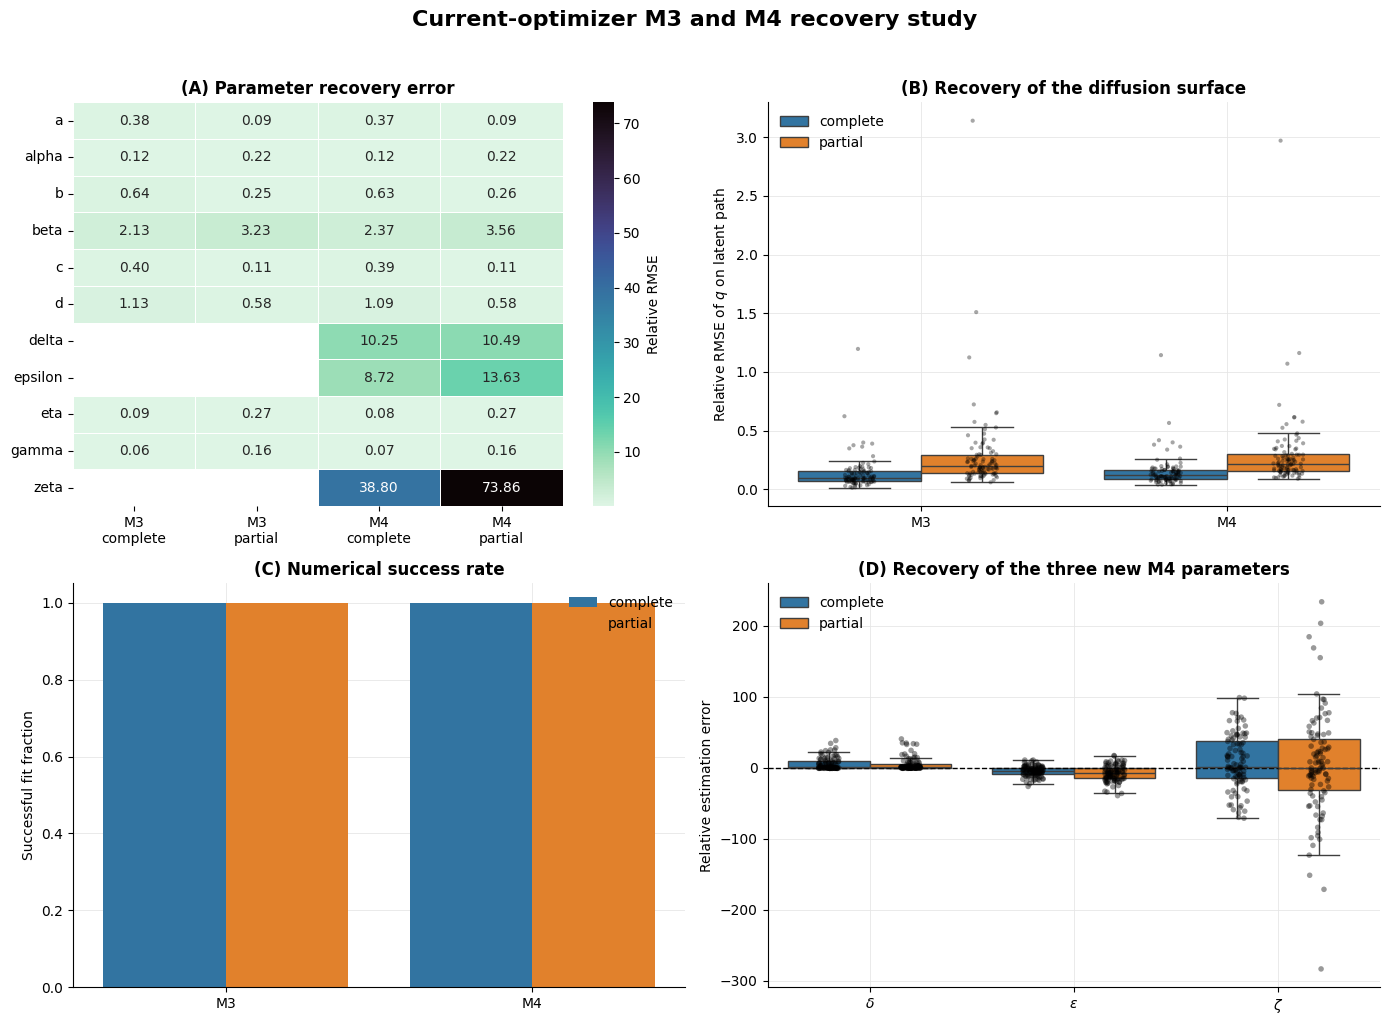

In [5]:
plot_recovery_study(
    recovery,
    config.REFERENCE_PARAMS_BY_MODEL,
    title="Current-optimizer M3 and M4 recovery study",
)
plt.show()


In [6]:
scenarios = ("m3", "weak", "moderate", "strong")
discrimination = pd.concat(
    [pd.read_csv(CURRENT / f"discrimination_{name}.csv") for name in scenarios],
    ignore_index=True,
)
discrimination.groupby("truth").agg(
    n=("success", "size"),
    success_rate=("success", "mean"),
    median_contrast=("contrast", "median"),
    m4_win_rate=("contrast", lambda values: np.mean(values > 0)),
)


,n,success_rate,median_contrast,m4_win_rate
truth,,,,
M3,100,1.0,3.812363,1.0
moderate,100,1.0,3.909928,1.0
strong,100,1.0,10.357856,1.0
weak,100,1.0,3.703360,1.0


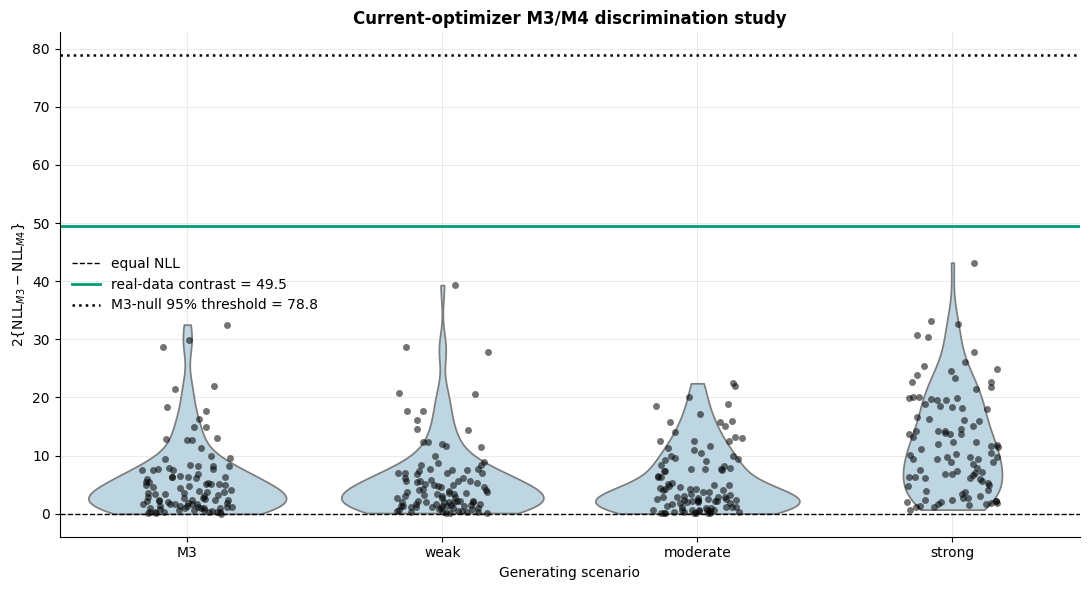

In [7]:
current_nested = pd.read_csv(CURRENT / "m3_m4_nested_summary.csv").iloc[0]
plot_discrimination(
    discrimination,
    float(current_nested["observed_contrast"]),
    title="Current-optimizer M3/M4 discrimination study",
    decision_threshold=float(current_nested["contrast_q95"]),
)
plt.show()


## 3. Real-data fitting and functional comparison

M2, M3, and M4 use the same data and corrected partial-observation
pseudo-likelihood. M4 adds position-dependent diffusion:

$$
q_{M4}(x,v)
=\alpha v^2+\beta v+\gamma+\delta x^2+\epsilon xv+\zeta x.
$$


In [8]:
fits[[
    "model", "n_free", "nll", "aic", "bic",
    "q_min_global", "q_min_observed", "time_sec",
]].round(4)


,model,n_free,nll,aic,bic,q_min_global,q_min_observed,time_sec
0,M2,6,8524.3477,17060.6954,17095.6373,4176.6681,4176.6681,310.4802
1,M3,8,8524.0589,17064.1179,17110.7070,4167.9462,4167.9462,538.5079
2,M4,11,8499.3116,17020.6233,17084.6834,0.0003,3867.0321,0.2531


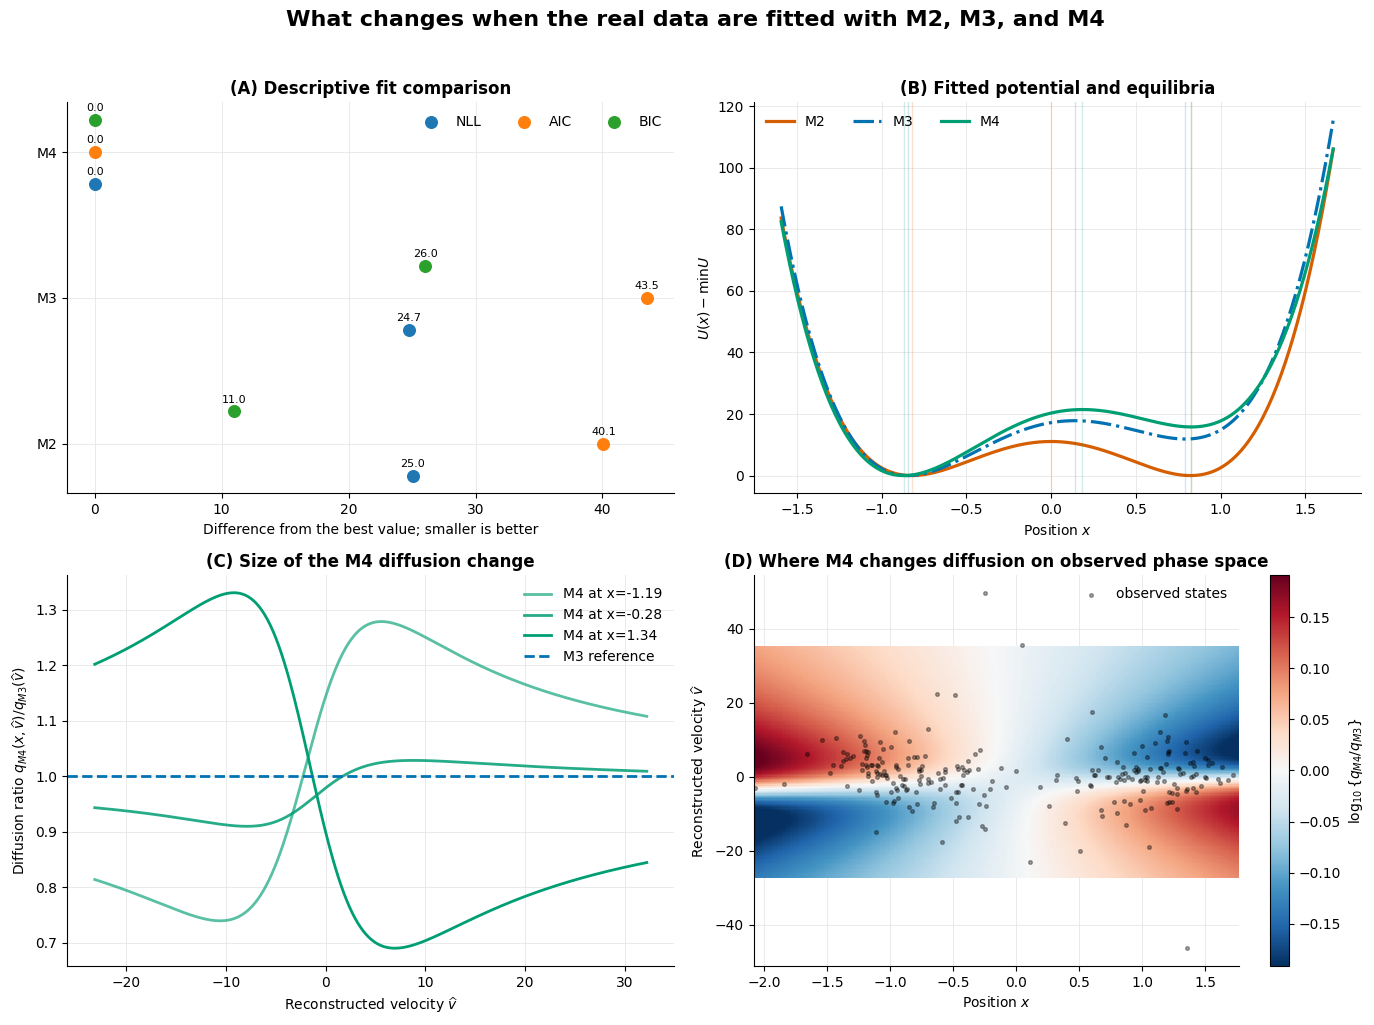

In [9]:
plot_real_data_mechanisms(fits, data)
plt.show()


## 4. Transition-level improvement and diffusion domain

The total M3-to-M4 improvement is decomposed into individual transition
contributions. A separate domain audit distinguishes the global minimum of
\(q\) from values supported by the observed state region.


In [10]:
transition = pd.read_csv(CURRENT / "transition_improvement.csv")
pd.Series({
    "NLL(M3)-NLL(M4)": transition["gain_m4_over_m3"].sum(),
    "fraction favouring M4": np.mean(transition["gain_m4_over_m3"] > 0),
    "largest positive gain": transition["gain_m4_over_m3"].max(),
    "largest negative gain": transition["gain_m4_over_m3"].min(),
})


NLL(M3)-NLL(M4)          24.747279
fraction favouring M4     0.559024
largest positive gain     5.915288
largest negative gain    -1.353872
dtype: float64

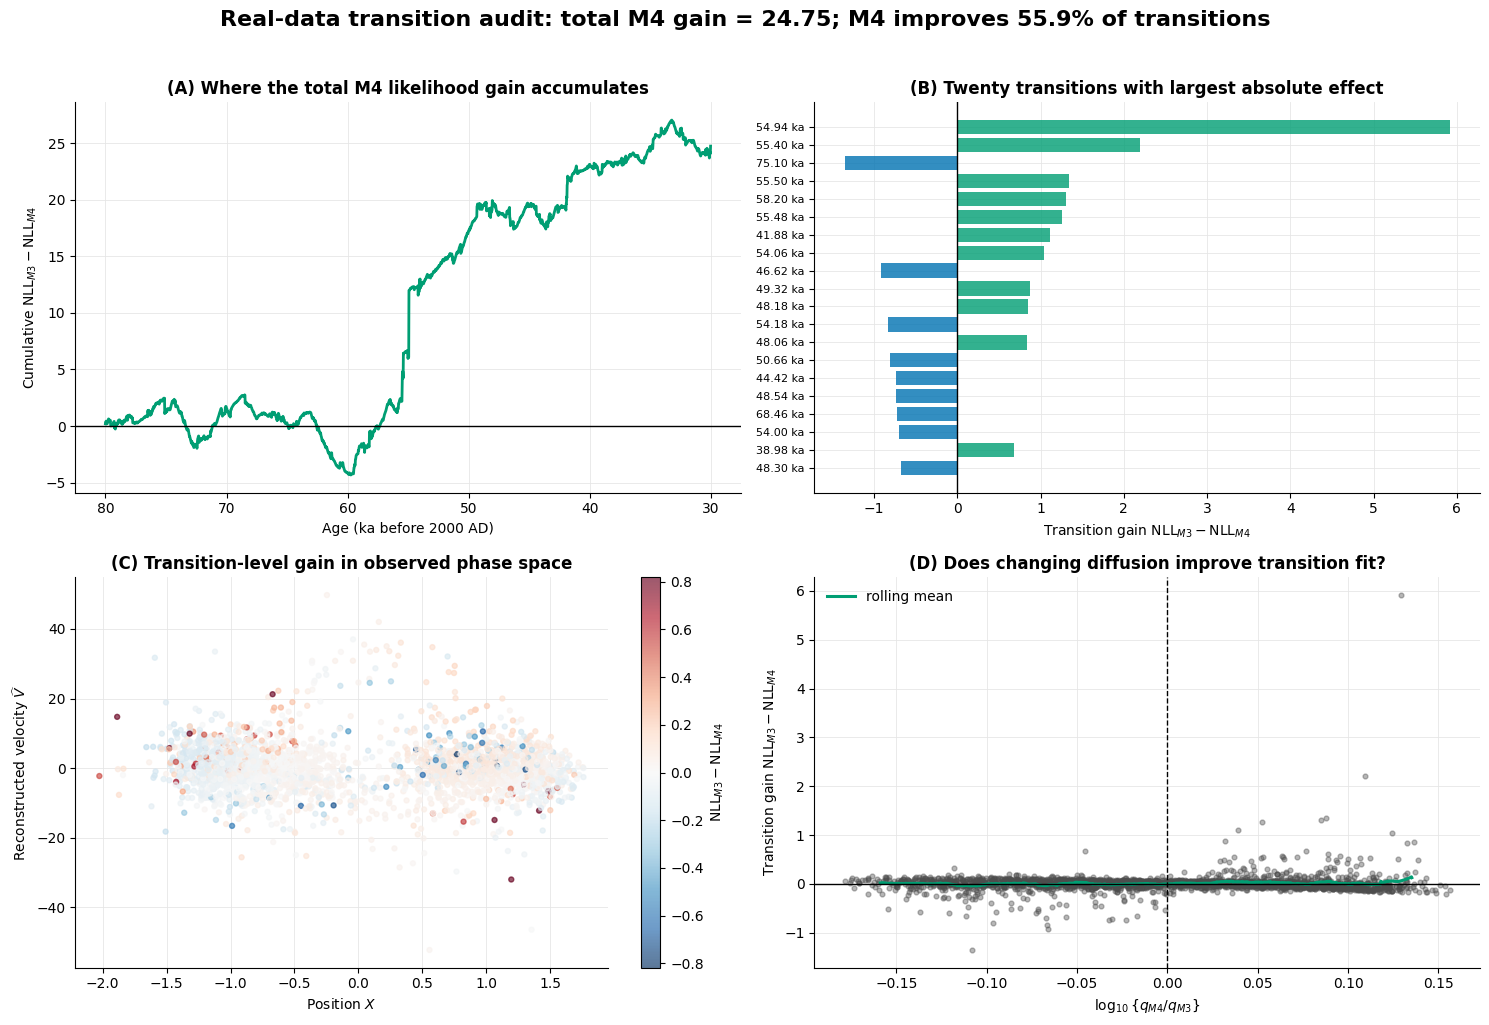

In [11]:
plot_transition_improvement(transition)
plt.show()


,model,q_min_global,q_min_observed_rectangle,q_path_min,q_min_standardized_distance
0,M2,4176.6681,4176.6681,4176.6694,0.2360
1,M3,4167.9462,4167.9462,4167.9465,0.2301
2,M4,0.0003,3867.0321,3869.1803,178.2785


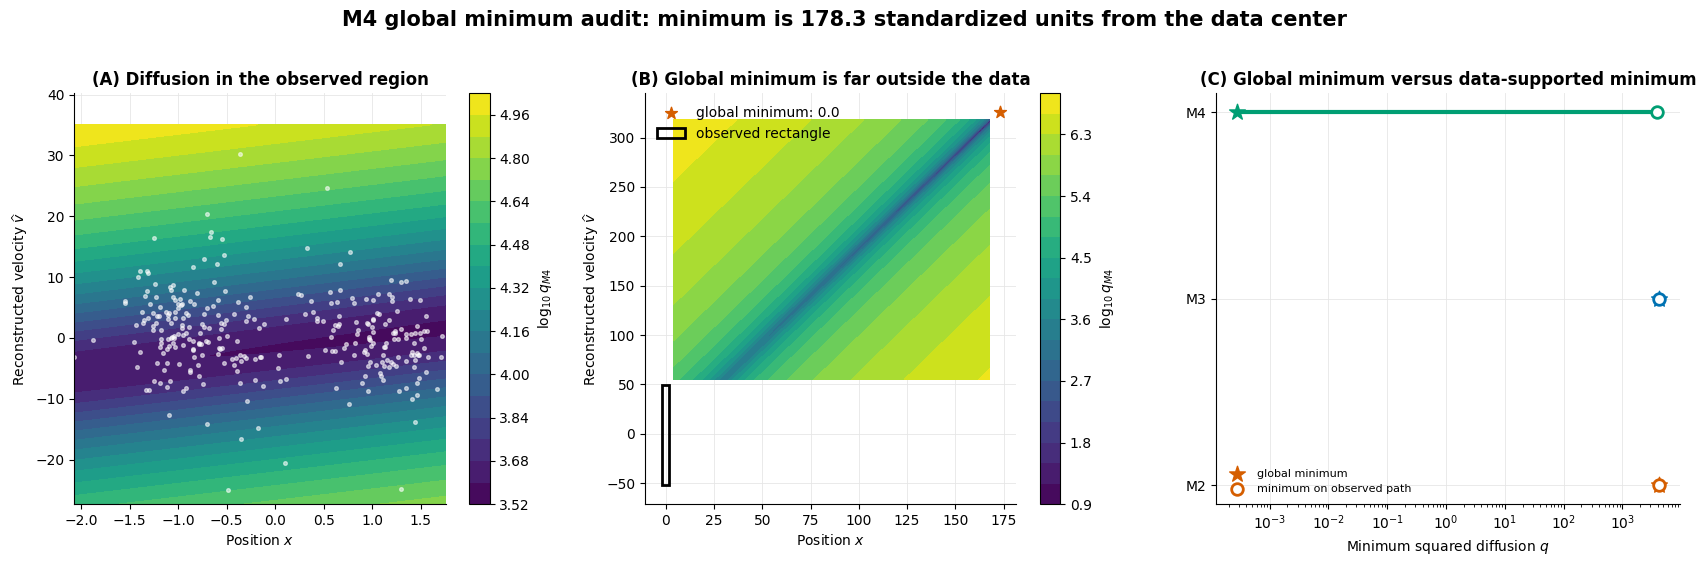

In [12]:
q_audit = pd.read_csv(CURRENT / "q_min_audit.csv")
display(q_audit[[
    "model", "q_min_global", "q_min_observed_rectangle",
    "q_path_min", "q_min_standardized_distance",
]].round(4))
plot_m4_diffusion_audit(fits, data, q_audit)
plt.show()


## 5. Predictive and regime diagnostics

For each fitted model, 100 current-fit trajectories were simulated. Their
latent velocities were discarded and reconstructed from simulated \(X\), so
the comparison uses the same observation scheme as the real data.


In [13]:
predictive = pd.read_csv(CURRENT / "predictive_comparison_summary.csv")
predictive.round(3)


,model,metric,observed,simulated_q025,simulated_median,simulated_q975,observed_percentile
0,M2,X_sd,1.001,0.765,0.853,0.928,1.00
1,M2,Vhat_sd,7.397,5.745,6.318,7.668,0.95
2,M2,lower_occupancy,0.548,0.353,0.547,0.728,0.51
3,M2,n_switches,45.000,42.475,63.500,96.150,0.08
4,M2,lower_wait_median,800.000,80.000,185.000,640.750,0.98
5,M2,upper_wait_median,520.000,80.000,205.000,740.500,0.93
6,M3,X_sd,1.001,0.707,0.851,0.952,1.00
7,M3,Vhat_sd,7.397,5.740,6.327,7.406,0.97
8,M3,lower_occupancy,0.548,0.386,0.588,0.785,0.32
9,M3,n_switches,45.000,37.950,63.500,89.050,0.13


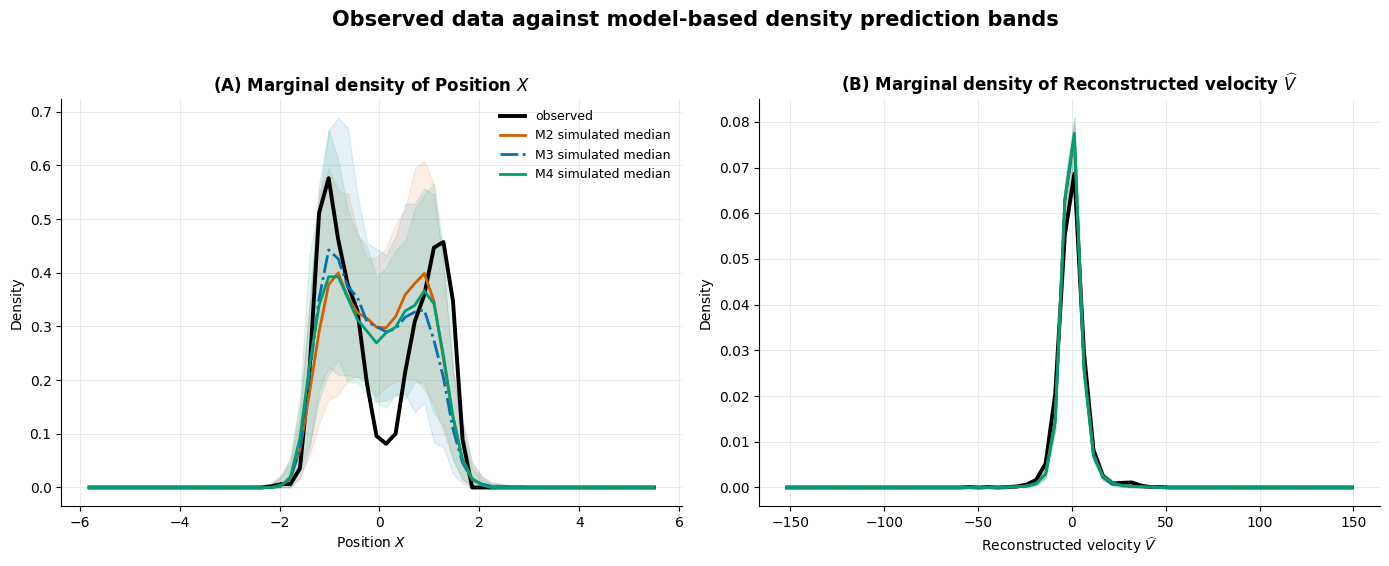

In [14]:
plot_predictive_densities(pd.read_csv(CURRENT / "predictive_density.csv"))
plt.show()


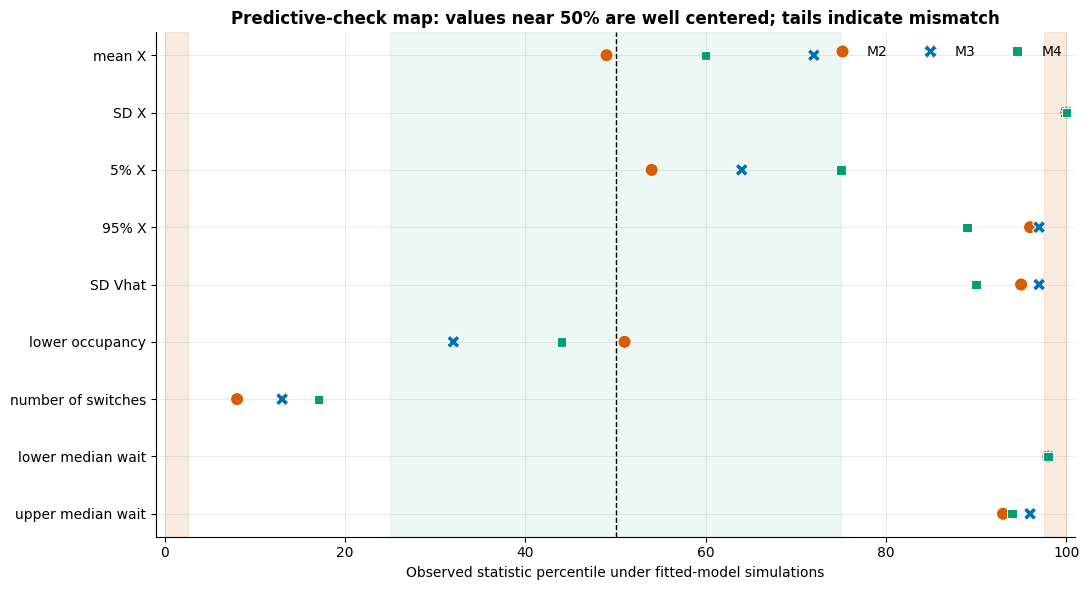

In [15]:
plot_predictive_percentiles(
    pd.read_csv(CURRENT / "predictive_summary.csv"),
    pd.read_csv(CURRENT / "predictive_behavior.csv"),
)
plt.show()


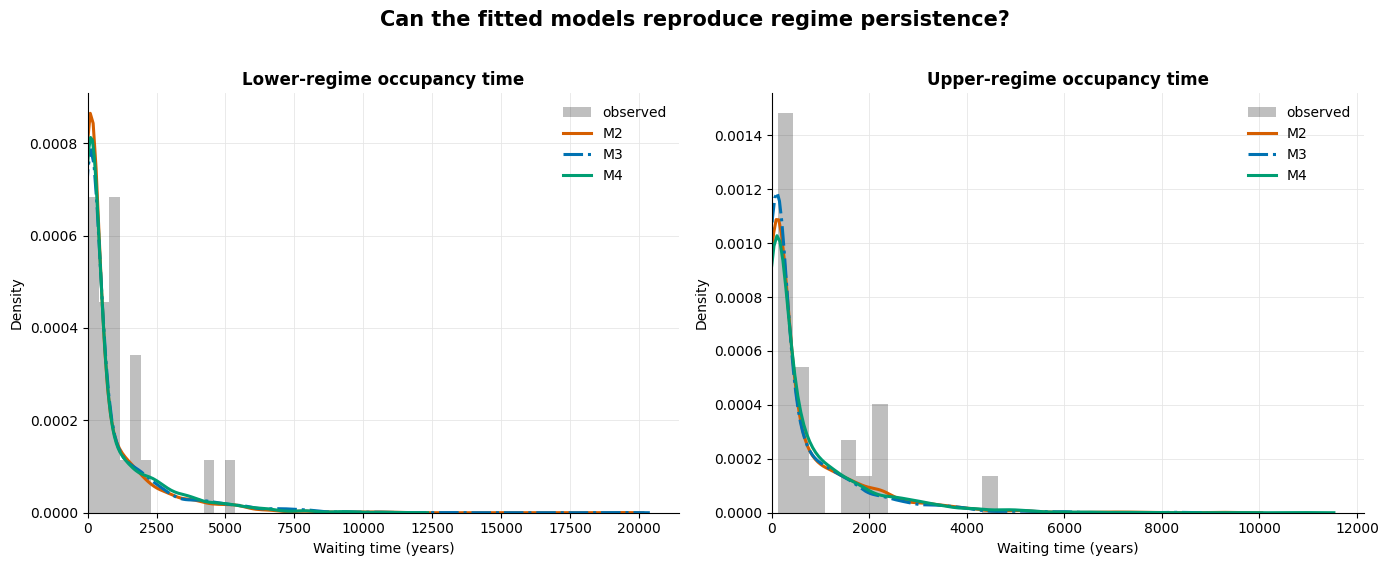

In [16]:
plot_waiting_time_comparison(pd.read_csv(CURRENT / "predictive_waiting.csv"))
plt.show()


## 6. Three bootstrap questions

The project uses three different bootstrap designs.

1. **M3-null nested bootstrap:** can M4 obtain the observed likelihood gain
   when M3 generates the data?
2. **M4 parametric bootstrap:** how uncertain are the M4 parameters and fitted
   diffusion function?
3. **M4 model-wise IOS bootstrap:** is observed leave-one-out sensitivity
   unusually large under fitted M4?

All three designs now use the current Cholesky optimizer where M4 is refitted.


In [17]:
bootstrap_overview = pd.read_csv(
    CURRENT / "m4_parametric_bootstrap_overview.csv"
)
bootstrap_overview.round(4)


,n_total,n_success,n_failed,success_rate,median_time_sec,total_time_sec,nll_mean,nll_sd,nll_q025,nll_q50,nll_q975
0,500,496,4,0.992,3.23,1667.6338,8139.0294,148.247,7874.5326,8131.5965,8464.943


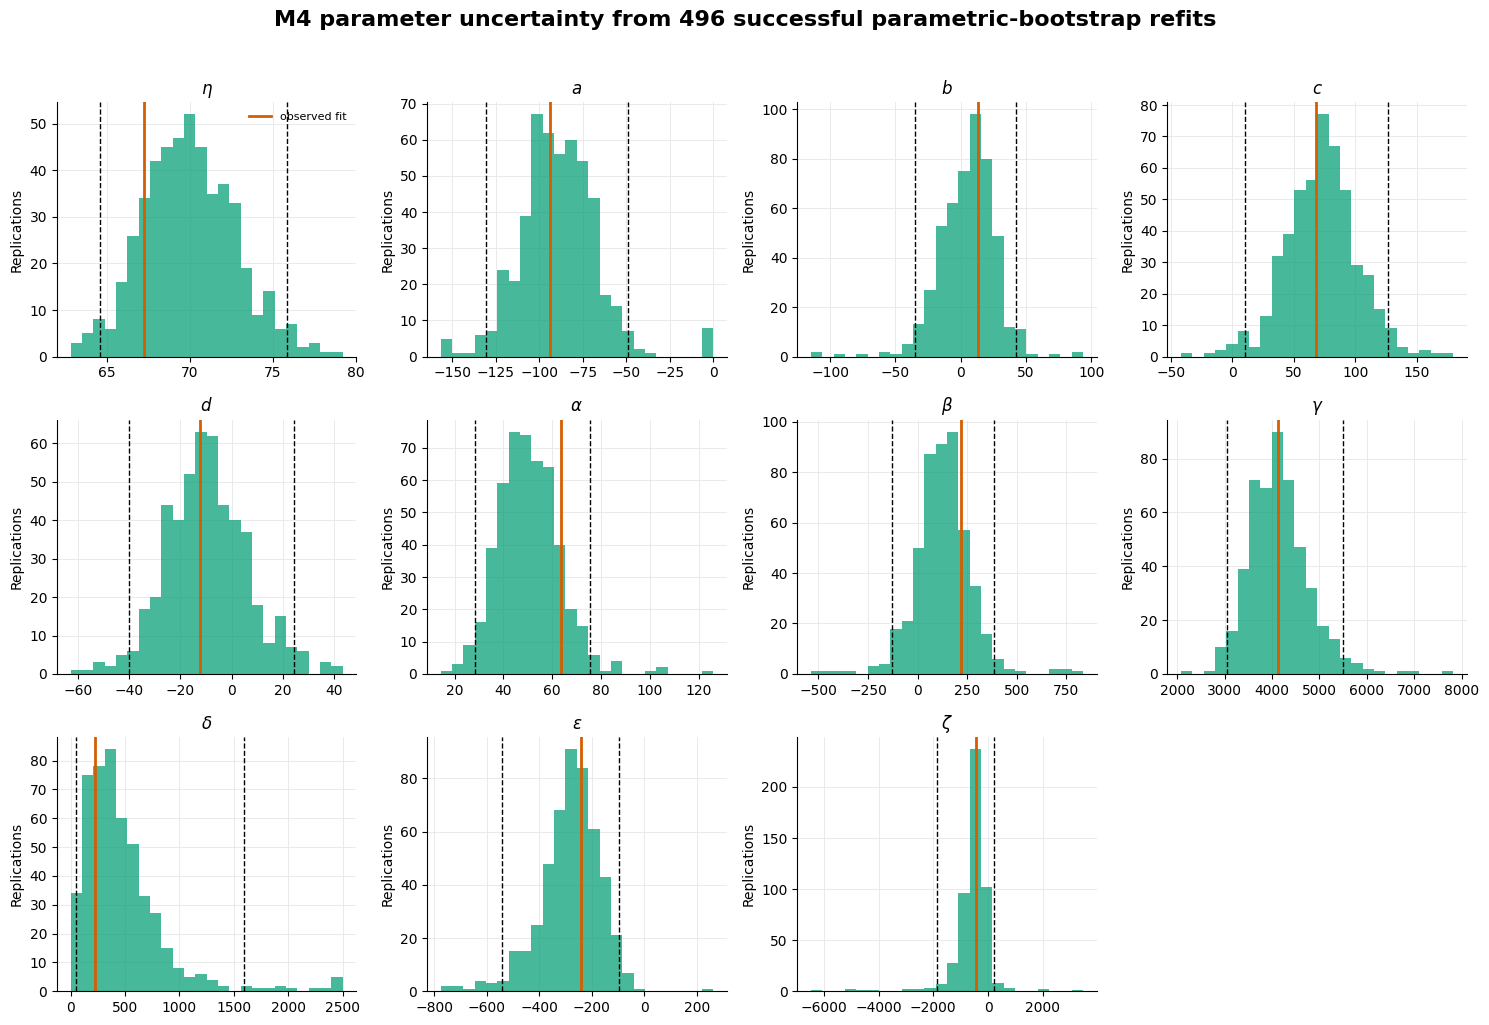

In [18]:
m4_bootstrap = pd.read_csv(CURRENT / "m4_parametric_bootstrap.csv")
plot_m4_parameter_distributions(m4_bootstrap, m4_params)
plt.show()


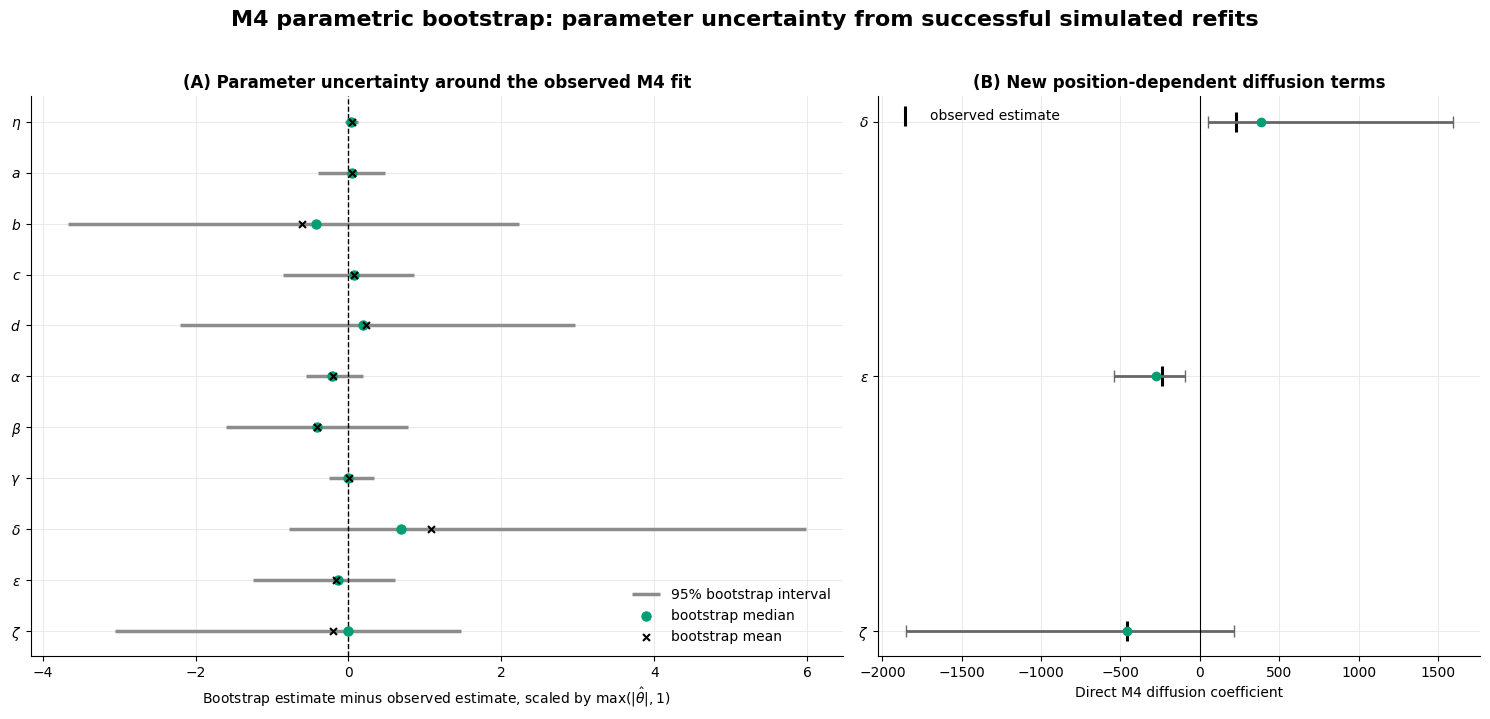

In [19]:
parameter_summary = pd.read_csv(
    CURRENT / "m4_parametric_bootstrap_parameters.csv"
)
plot_m4_parametric_bootstrap_parameters(parameter_summary)
plt.show()


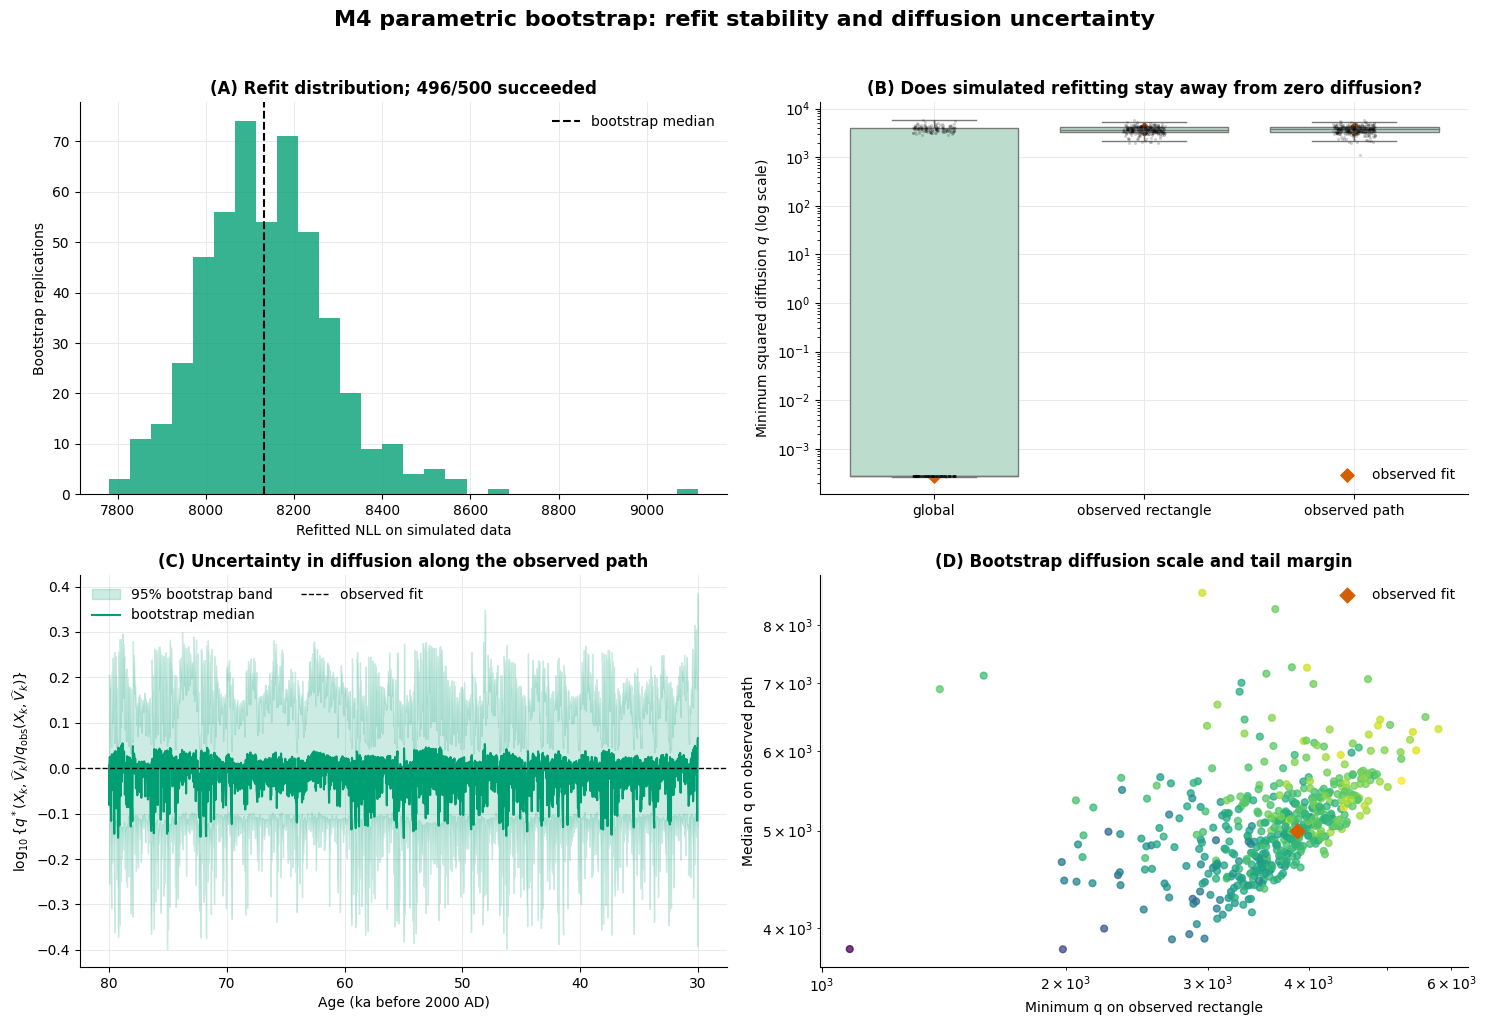

In [20]:
plot_m4_parametric_bootstrap_diffusion(
    bootstrap_overview,
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_diffusion.csv"),
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_diffusion_summary.csv"),
    pd.read_csv(CURRENT / "m4_parametric_bootstrap_path_band.csv"),
)
plt.show()


In [21]:
pd.read_csv(CURRENT / "m4_bootstrap_derived_summary.csv").round(4)


,metric,observed,n_finite,q025,median,q975
0,lower_well,-0.8707,417,-1.1044,-0.9421,-0.7136
1,barrier,0.1852,417,-0.3359,0.1175,0.4792
2,upper_well,0.8264,417,0.5893,0.8991,1.0812
3,Delta_U_lower,21.4602,417,2.5878,24.0083,56.9540
4,Delta_U_upper,5.6571,417,0.2134,12.2042,42.4217
5,q_min,0.0003,496,0.0003,0.0003,4801.3382
6,q_min_x,172.8843,496,-0.0557,8.4840,477.4990
7,q_min_v,325.8302,496,-0.7443,14.5297,1305.5836
8,nu_proxy,3.1187,496,2.8326,3.8230,5.8891


### Current M3-null bootstrap

The formal run generated 100 partial-observation samples from current fitted
M3. It used 8 starts for M3 and 12 starts for Cholesky M4. Thirteen null
contrasts were at least as large as the observed contrast.


,observed_contrast,n_boot,n_valid,n_failed,success_rate,contrast_mean,contrast_median,contrast_q025,contrast_q95,contrast_q975,contrast_q99,n_exceed,p_upper,p_upper_mcse,exceedance_ci95_low,exceedance_ci95_high,extend_to_300,median_time_sec,total_time_hours
0,49.4946,100,100,0,1.0,36.1268,15.3154,2.1382,78.8478,207.6151,558.7967,13,0.1386,0.0344,0.0711,0.212,False,61.5467,1.7872


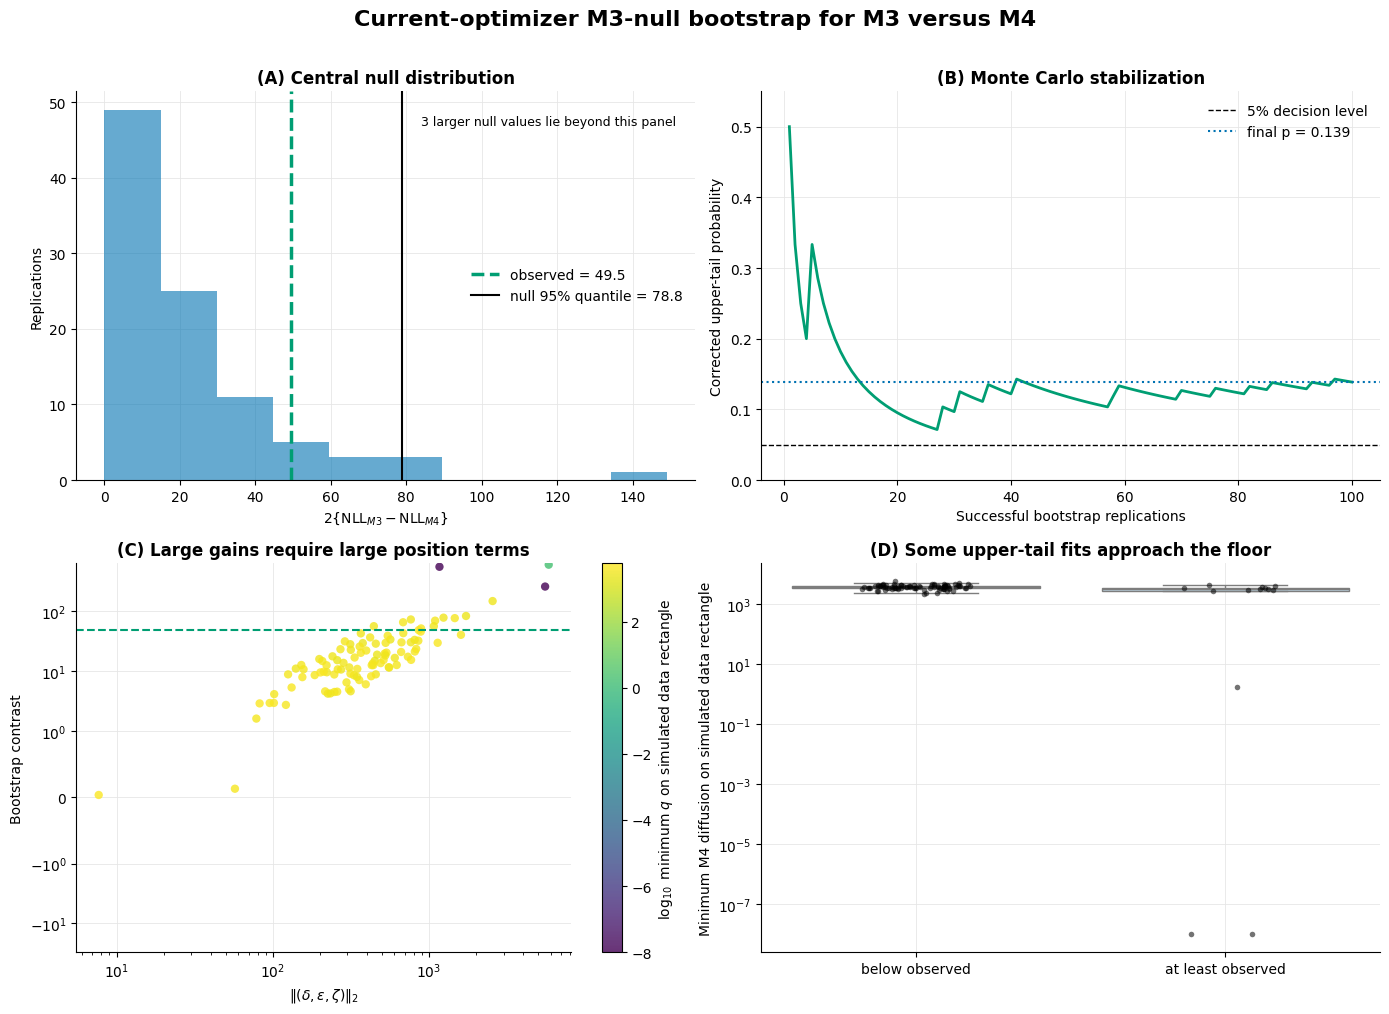

In [22]:
display(pd.read_csv(CURRENT / "m3_m4_nested_summary.csv").round(4))
plot_nested_bootstrap_diagnostics(
    pd.read_csv(CURRENT / "m3_m4_nested_bootstrap.csv"),
    pd.read_csv(CURRENT / "m3_m4_nested_cumulative.csv"),
    float(current_nested["observed_contrast"]),
)
plt.show()


## 7. Exact information-omission sensitivity

For transition \(k\),

$$
\operatorname{IOS}_k
=\ell_k(\widehat\theta_{-k})-\ell_k(\widehat\theta),
\qquad
T_N=\sum_k\operatorname{IOS}_k.
$$

All 2499 transitions were recomputed for M2, M3, and M4.


In [23]:
ios_summary = pd.read_csv(CURRENT / "ios_comparison.csv")
ios_summary[[
    "model", "T_N", "n_valid", "success_rate",
    "fraction_transitions_for_80pct_positive", "total_seconds",
]].round(4)


,model,T_N,n_valid,success_rate,fraction_transitions_for_80pct_positive,total_seconds
0,M2,8.5893,2499,1.0,0.0240,123.1121
1,M3,11.5488,2499,1.0,0.0340,182.1718
2,M4,21.8765,2499,1.0,0.0864,3793.8558


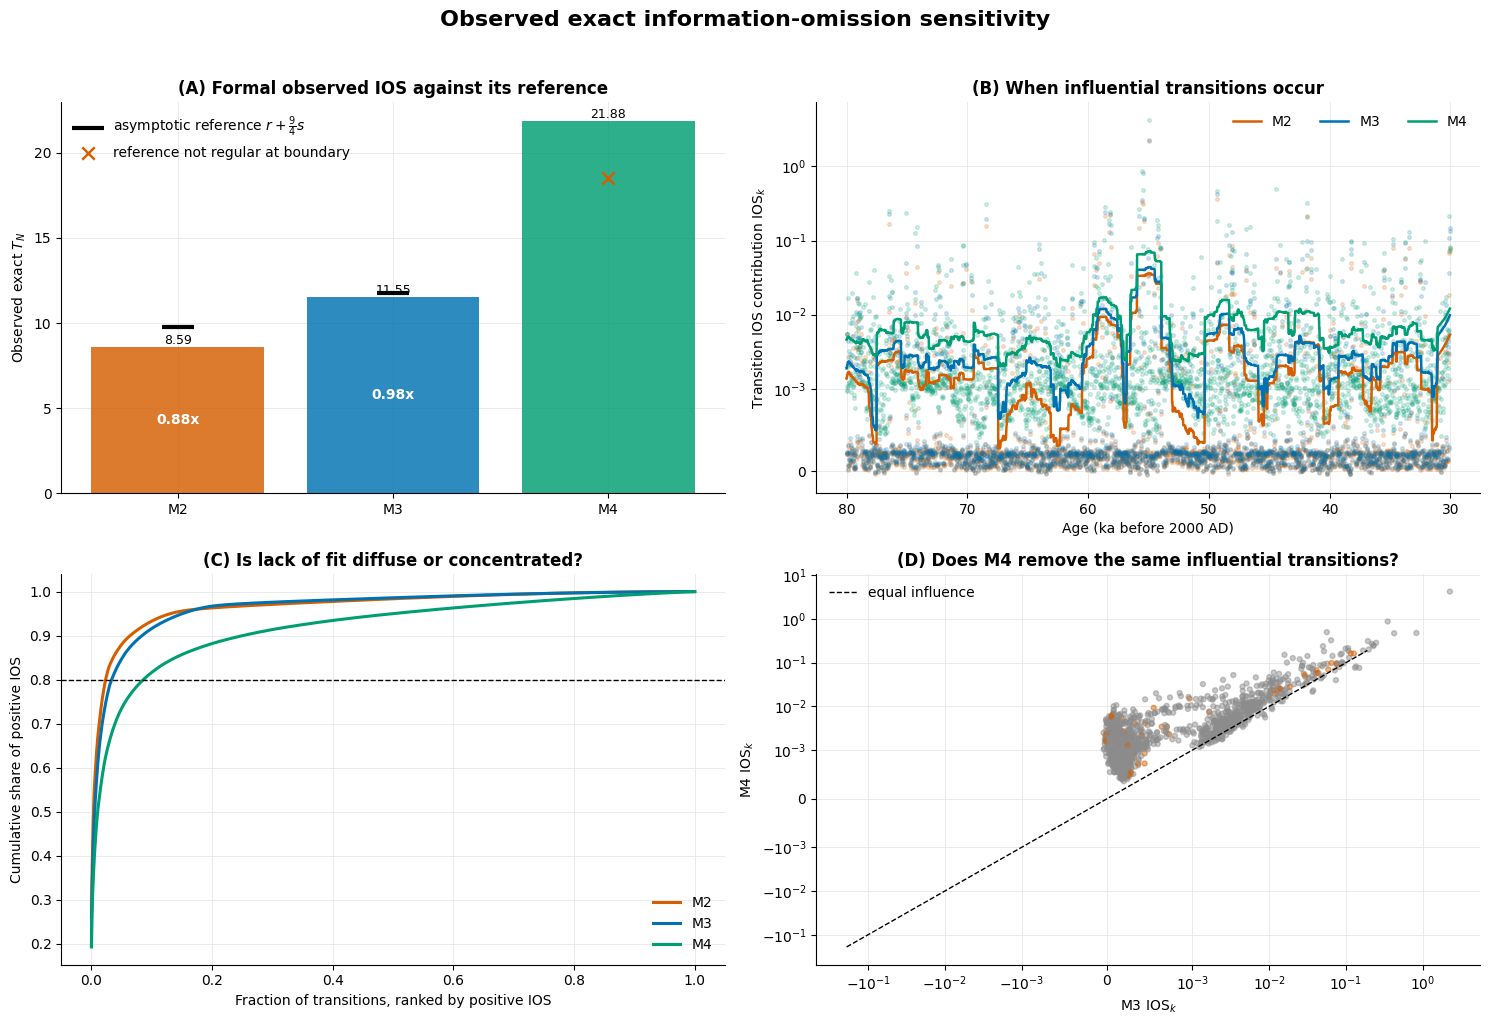

In [24]:
ios_transitions = pd.read_csv(CURRENT / "ios_transitions.csv")
plot_ios_overview(ios_summary, ios_transitions)
plt.show()


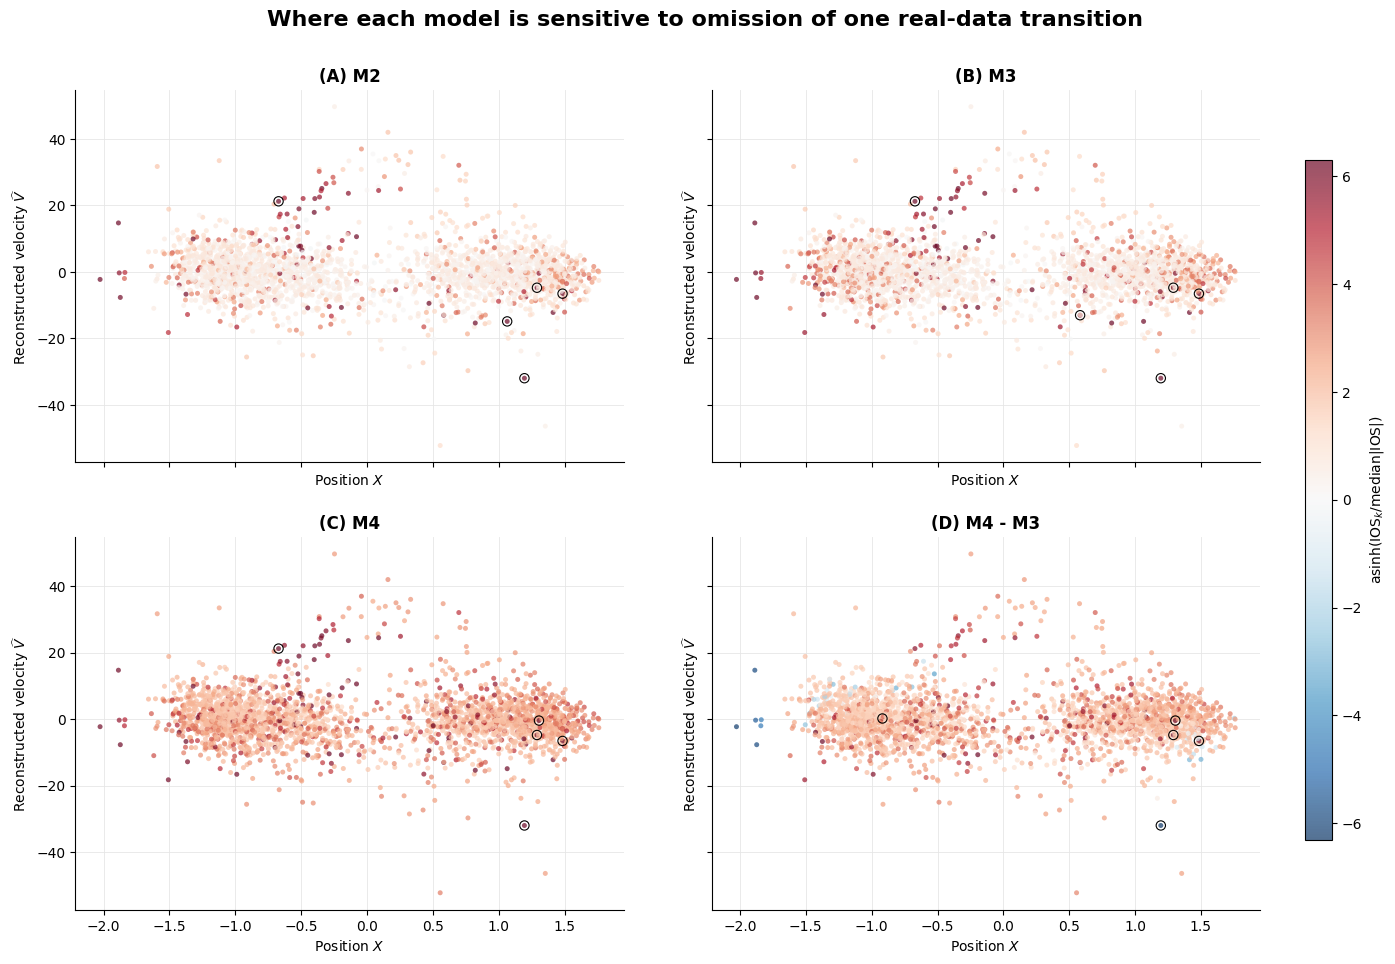

In [25]:
plot_ios_phase_space(ios_transitions)
plt.show()


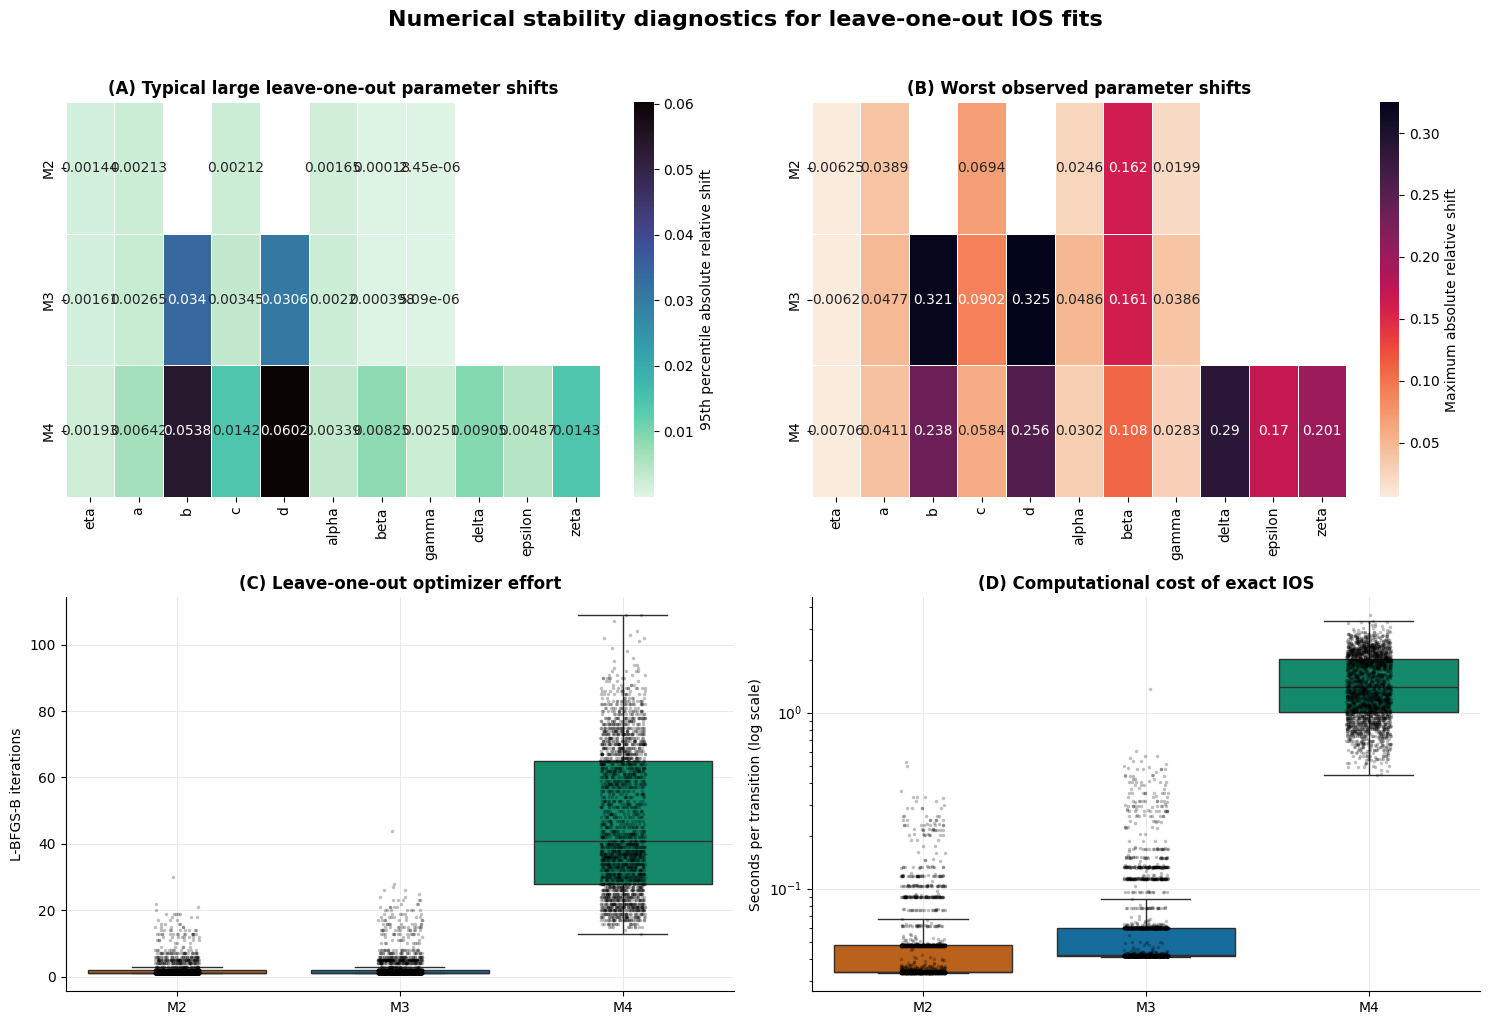

In [26]:
plot_ios_numerical_diagnostics(
    pd.read_csv(CURRENT / "ios_parameter_shifts.csv"),
    ios_transitions,
)
plt.show()


## 8. Model-wise M4 IOS bootstrap

Each replication simulates from fitted M4, refits M4, and recomputes all 2499
leave-one-out fits. This calibrates the IOS statistic under the full current
estimation pipeline.


In [27]:
modelwise_summary = pd.read_csv(
    CURRENT / "m4_modelwise_ios_bootstrap_summary.csv"
)
modelwise_summary.round(4)


,model,observed_T_N,n_total,n_success,n_failed,success_rate,mean,sd,q025,q50,q975,p_upper,p_lower,observed_percentile,median_time_sec,total_time_sec,median_ios_seconds
0,M4,21.8765,200,200,0,1.0,50.6782,37.8945,21.0893,39.8286,154.8007,0.9652,0.0398,0.035,3219.3252,678314.4388,3130.3531


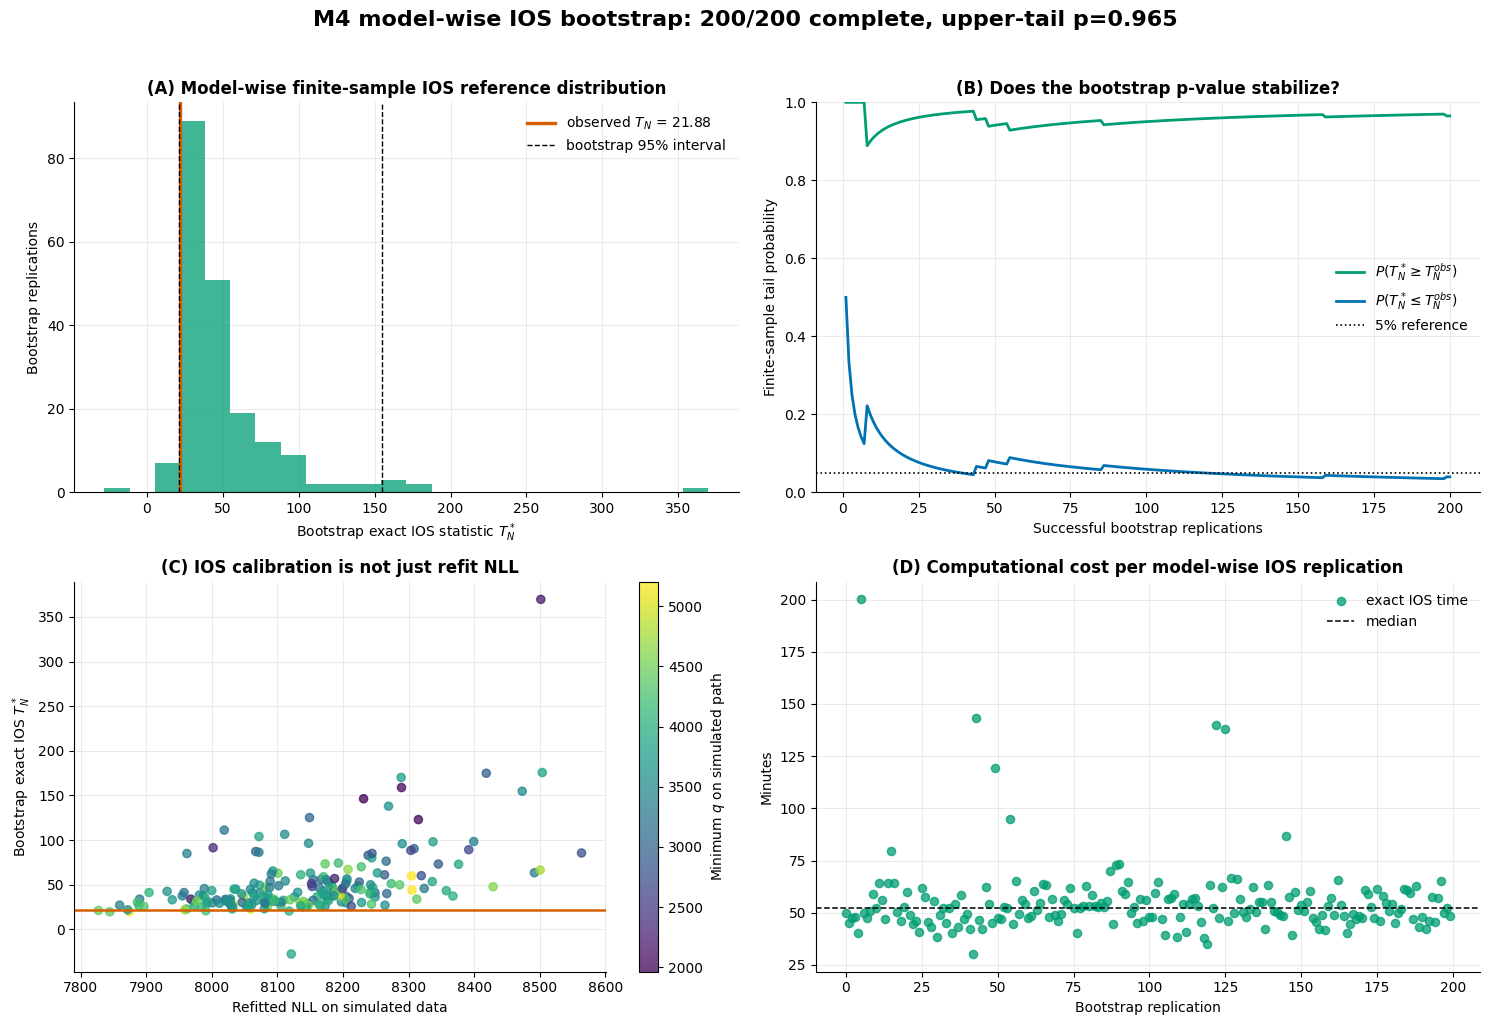

In [28]:
plot_modelwise_ios_bootstrap(
    modelwise_summary,
    pd.read_csv(CURRENT / "m4_modelwise_ios_bootstrap_cumulative.csv"),
    pd.read_csv(CURRENT / "m4_modelwise_ios_bootstrap.csv"),
)
plt.show()


## 9. Current conclusion

The current evidence shows that M4 is numerically viable, improves the
real-data objective, changes the fitted diffusion over observed phase space,
and does not have unusually large IOS under its own bootstrap calibration.

The predictive simulations still switch more often than the observed path,
and the position distribution remains too narrow. M4 therefore improves the
local likelihood without solving every model-check discrepancy.

The current M3-null nested bootstrap gives an upper-tail probability of
0.1386 and a null 95% threshold of 78.848. The observed contrast 49.495 does
not select M4 over M3 at the 5% level.

Current recovery succeeds numerically, but the three new M4 coefficients are
much less stable than the fitted diffusion function. The present
discrimination scenarios are all below the calibrated null threshold and
should be redesigned using functional separation in \(q(x,v)\).


## 10. Reproducibility commands

```bash
python3 -m greenland_application.run_report_assets --refresh-snapshot
quarto render docs/M4_GREENLAND_RESEARCH_REPORT.md --to html
quarto render docs/M4_GREENLAND_RESEARCH_REPORT.md --to pdf
python3 -m unittest discover tests -v
```
